# 08 - Cross-Representation TDA Comparison

Notebook 07 treated the FLUX diagram as pipeline-sensitive unless it
survives controls. This notebook asks a complementary question:

> If we keep the TDA pipeline fixed, do different image representations
> produce different topological fingerprints?

The comparison includes continuous diffusion VAEs, a VQ-style tokenizer,
transformer patch embeddings, CLIP vision patch embeddings, and raw
image patches. This is still exploratory: the goal is to find promising
contrasts, not to rank encoders.

## What Is Held Fixed?

For every representation we use the same high-level pipeline:

```text
images
  -> encoder or patch extractor
  -> spatial/local token vectors
  -> L2-normalize token vectors to a unit sphere
  -> select a dense subset by kth-nearest-neighbor distance
  -> choose farthest-point landmarks
  -> run Vietoris-Rips persistent homology
  -> compare observed landmarks to simple controls
```

The token dimension and grid size differ across representations. That is
part of the object being compared, so the plots report normalized
persistence as `persistence / filtration_threshold` in addition to raw
counts.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import os
import sys
import time
import warnings

for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import pdist

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The input point cloud has more columns than rows.*")
plt.rcParams["figure.max_open_warning"] = 120
sns.set_theme(style="whitegrid", context="notebook")

from notebook_utils.encoder_explorer import (
    DEFAULT_IMAGE_DIR,
    choose_device,
    code_usage_table,
    extract_token_clouds,
    l2_normalize,
    load_project_images,
    seed_everything,
    shape_summary,
    show_image_grid,
    token_norm_table,
)
from notebook_utils.flux_tda import (
    TDASample,
    build_observed_tda_sample,
    build_random_sphere_sample,
    build_uniform_sphere_sample,
    plot_betti_curves,
    plot_diagrams,
    ripser_diagrams,
    top_persistence_table,
)

## 1. Runtime Knobs

The default run uses all encoder families that were introduced earlier.
Set `TOKENIZER_ENCODERS` to a comma-separated subset when iterating.

In [2]:
def parse_int_list(text: str) -> list[int]:
    return [int(part.strip()) for part in text.split(",") if part.strip()]


def parse_str_list(text: str) -> list[str]:
    return [part.strip() for part in text.split(",") if part.strip()]


SEED = int(os.environ.get("TOKENIZER_NOTEBOOK_SEED", "72"))
SMOKE = os.environ.get("TOKENIZER_SMOKE", "0") == "1"

default_encoders = "flux_vae,sd_vae_ft_mse,kandinsky_movq,vit_base_patch16,clip_vit_base_patch32,raw_patches"
smoke_encoders = "flux_vae,sd_vae_ft_mse,raw_patches"
SELECTED = parse_str_list(os.environ.get("TOKENIZER_ENCODERS", smoke_encoders if SMOKE else default_encoders))

N_IMAGES = int(os.environ.get("TOKENIZER_N_IMAGES", "4" if SMOKE else "12"))
BATCH_SIZE = int(os.environ.get("TOKENIZER_BATCH_SIZE", "2" if SMOKE else "4"))
AUTOENCODER_SIZE = int(os.environ.get("TOKENIZER_AUTOENCODER_SIZE", "256"))
VIT_SIZE = int(os.environ.get("TOKENIZER_VIT_SIZE", "224"))
IMAGE_DIR = os.environ.get("TOKENIZER_IMAGE_DIR", str(DEFAULT_IMAGE_DIR))

COMPARISON_SEEDS = parse_int_list(os.environ.get("TOKENIZER_COMPARISON_SEEDS", "72" if SMOKE else "72,73"))
N_DENSE = int(os.environ.get("TOKENIZER_COMPARISON_N_DENSE", "250" if SMOKE else "500"))
N_LANDMARKS = int(os.environ.get("TOKENIZER_COMPARISON_N_LANDMARKS", "45" if SMOKE else "75"))
K_DENSITY = int(os.environ.get("TOKENIZER_COMPARISON_K_DENSITY", "10" if SMOKE else "16"))
MAXDIM = int(os.environ.get("TOKENIZER_COMPARISON_MAXDIM", "2"))
DISTANCE_QUANTILE = float(os.environ.get("TOKENIZER_COMPARISON_DISTANCE_QUANTILE", "0.82"))

seed_everything(SEED)
DEVICE = choose_device(force_cpu=os.environ.get("TOKENIZER_FORCE_CPU", "0") == "1")

display(
    pd.DataFrame(
        [
            {"knob": "device", "value": DEVICE},
            {"knob": "smoke", "value": SMOKE},
            {"knob": "selected", "value": SELECTED},
            {"knob": "n_images", "value": N_IMAGES},
            {"knob": "seeds", "value": COMPARISON_SEEDS},
            {"knob": "n_dense", "value": N_DENSE},
            {"knob": "n_landmarks", "value": N_LANDMARKS},
            {"knob": "k_density", "value": K_DENSITY},
            {"knob": "maxdim", "value": MAXDIM},
            {"knob": "distance_quantile", "value": DISTANCE_QUANTILE},
            {"knob": "image_dir", "value": IMAGE_DIR},
        ]
    )
)

,knob,value
0,device,mps
1,smoke,False
2,selected,"[flux_vae, sd_vae_ft_mse, kandinsky_movq, vit_..."
3,n_images,12
4,seeds,"[72, 73]"
5,n_dense,500
6,n_landmarks,75
7,k_density,16
8,maxdim,2
9,distance_quantile,0.82


## 2. Load Images

The same image subset is used for every representation. Labels are shown
only to help interpret what the local patches came from; the TDA object
is the token distribution.

,image_id,source,path,label,dataset_index,width,height
0,0,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,0,500,500
1,1,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,345,500,500
2,2,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,693,500,500
3,3,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,1,500,500
4,4,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,346,500,500
5,5,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,694,500,500
6,6,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,2,500,500
7,7,beans,/Users/vitaly/Code/latent-space-topology/data/...,bean_rust,347,500,500
8,8,beans,/Users/vitaly/Code/latent-space-topology/data/...,healthy,695,500,500
9,9,beans,/Users/vitaly/Code/latent-space-topology/data/...,angular_leaf_spot,3,500,500


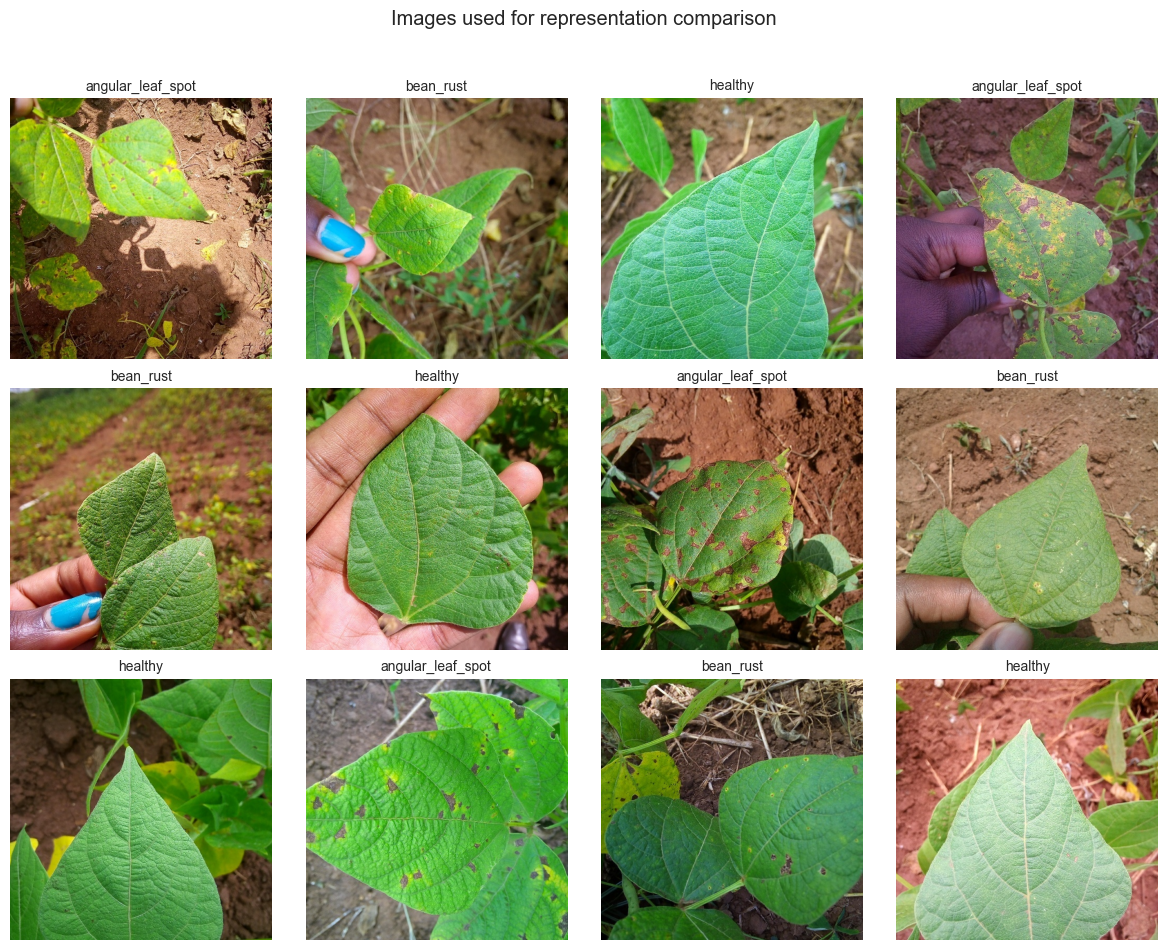

In [3]:
images, image_metadata = load_project_images(N_IMAGES, IMAGE_DIR)
display(image_metadata.head(12))
show_image_grid(images, image_metadata, n=min(12, len(images)), title="Images used for representation comparison")

## 3. Extract Token Clouds

This cell may download model weights on a fresh machine. Once cached, the
full default set usually runs quickly enough for exploratory work.

In [4]:
t0 = time.perf_counter()
token_clouds, failures = extract_token_clouds(
    images,
    image_metadata,
    device=DEVICE,
    batch_size=BATCH_SIZE,
    autoencoder_size=AUTOENCODER_SIZE,
    vit_size=VIT_SIZE,
    selected=SELECTED,
)
encode_seconds = time.perf_counter() - t0

if not failures.empty:
    display(failures)

print(f"encoding seconds: {encode_seconds:.2f}")
display(shape_summary(token_clouds))
display(token_norm_table(token_clouds).round(4))

Running flux_vae: diffusers/FLUX.1-vae


/Users/vitaly/Code/latent-space-topology/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  ok: (12288, 16), grid=(32, 32), elapsed=5.8s
Running sd_vae_ft_mse: stabilityai/sd-vae-ft-mse


/Users/vitaly/Code/latent-space-topology/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  ok: (12288, 4), grid=(32, 32), elapsed=3.3s
Running kandinsky_movq: kandinsky-community/kandinsky-2-2-decoder/movq


...

  ok: (2352, 768), grid=(14, 14), elapsed=1.7s
Running clip_vit_base_patch32: openai/clip-vit-base-patch32


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  ok: (588, 768), grid=(7, 7), elapsed=2.2s
Running raw_patches: raw_image_patches
  ok: (3072, 768), grid=(16, 16), elapsed=0.1s
encoding seconds: 16.55


,name,family,token_kind,tokens_shape,grid_shape,channel_dim,model_id
0,flux_vae,AutoencoderKL,posterior_mean,"(12288, 16)","(32, 32)",16,diffusers/FLUX.1-vae
1,sd_vae_ft_mse,AutoencoderKL,posterior_mean,"(12288, 4)","(32, 32)",4,stabilityai/sd-vae-ft-mse
2,kandinsky_movq,VQModel,quantized_embedding,"(12288, 4)","(32, 32)",4,kandinsky-community/kandinsky-2-2-decoder/movq
3,vit_base_patch16,ViT,contextual_patch_embedding,"(2352, 768)","(14, 14)",768,google/vit-base-patch16-224-in21k
4,clip_vit_base_patch32,CLIPVision,contextual_patch_embedding,"(588, 768)","(7, 7)",768,openai/clip-vit-base-patch32
5,raw_patches,RawPatches,centered_contrast_patch,"(3072, 768)","(16, 16)",768,raw_image_patches


,name,family,mean_norm,std_norm,cv_norm,min_norm,max_norm
0,flux_vae,AutoencoderKL,7.960200,1.6786,0.2109,2.5881,17.464800
1,sd_vae_ft_mse,AutoencoderKL,7.995400,3.0525,0.3818,0.7671,42.325298
2,kandinsky_movq,VQModel,0.739900,0.2757,0.3726,0.0498,1.971600
3,vit_base_patch16,ViT,5.433800,0.7481,0.1377,1.8797,5.775200
4,clip_vit_base_patch32,CLIPVision,17.307199,1.0693,0.0618,14.4590,21.468901
5,raw_patches,RawPatches,1.000000,0.0000,0.0000,1.0000,1.000000


## 4. Representation Notes

The same word "token" hides several different objects. The table below
keeps those differences visible before comparing diagrams.

In [5]:
representation_rows = []
for name, cloud in token_clouds.items():
    norms = np.linalg.norm(cloud.tokens, axis=1)
    row = {
        "cloud": name,
        "family": cloud.family,
        "token_kind": cloud.token_kind,
        "n_tokens": len(cloud.tokens),
        "channel_dim": cloud.channel_dim,
        "grid_shape": cloud.grid_shape,
        "mean_norm": float(norms.mean()),
        "std_norm": float(norms.std()),
        "cv_norm": float(norms.std() / max(norms.mean(), 1e-12)),
        "model_id": cloud.model_id,
    }
    if cloud.code_indices is not None:
        usage = code_usage_table(cloud)
        row["unique_codes"] = len(usage)
        row["top_code_frequency"] = float(usage["frequency"].iloc[0])
    representation_rows.append(row)

representation_table = pd.DataFrame(representation_rows)
display(representation_table)

if "kandinsky_movq" in token_clouds and token_clouds["kandinsky_movq"].code_indices is not None:
    print("Top Kandinsky / MoVQ code usage")
    display(code_usage_table(token_clouds["kandinsky_movq"]).head(12))

,cloud,family,token_kind,n_tokens,channel_dim,grid_shape,mean_norm,std_norm,cv_norm,model_id,unique_codes,top_code_frequency
0,flux_vae,AutoencoderKL,posterior_mean,12288,16,"(32, 32)",7.960248,1.678583e+00,2.108707e-01,diffusers/FLUX.1-vae,NaN,NaN
1,sd_vae_ft_mse,AutoencoderKL,posterior_mean,12288,4,"(32, 32)",7.995409,3.052506e+00,3.817824e-01,stabilityai/sd-vae-ft-mse,NaN,NaN
2,kandinsky_movq,VQModel,quantized_embedding,12288,4,"(32, 32)",0.739890,2.756906e-01,3.726102e-01,kandinsky-community/kandinsky-2-2-decoder/movq,5369.0,0.001221
3,vit_base_patch16,ViT,contextual_patch_embedding,2352,768,"(14, 14)",5.433775,7.480540e-01,1.376674e-01,google/vit-base-patch16-224-in21k,NaN,NaN
4,clip_vit_base_patch32,CLIPVision,contextual_patch_embedding,588,768,"(7, 7)",17.307199,1.069329e+00,6.178521e-02,openai/clip-vit-base-patch32,NaN,NaN
5,raw_patches,RawPatches,centered_contrast_patch,3072,768,"(16, 16)",1.000000,4.436590e-08,4.436590e-08,raw_image_patches,NaN,NaN


Top Kandinsky / MoVQ code usage


,code,count,frequency
0,3528,15,0.001221
1,15544,14,0.001139
2,14294,13,0.001058
3,8388,12,0.000977
4,5728,11,0.000895
5,6665,11,0.000895
6,14805,11,0.000895
7,14842,11,0.000895
8,15335,11,0.000895
9,118,10,0.000814


## 5. Comparison Helpers

Controls are intentionally cheap:

- `observed_dense`: dense sphere landmarks from the representation;
- `random_tokens`: random sphere-normalized tokens from the same cloud;
- `uniform_sphere`: random directions in the same ambient dimension;
- `diag_gaussian`: independent per-channel Gaussian matched to the raw
  token mean and standard deviation, then sphere-normalized.

The diagonal Gaussian is not a full covariance control. It is a fast
baseline for marginal scale effects.

In [6]:
def build_diag_gaussian_sphere_sample(cloud, n_landmarks: int, seed: int) -> TDASample:
    rng = np.random.default_rng(seed)
    raw = cloud.tokens.astype(np.float32)
    mean = raw.mean(axis=0)
    std = raw.std(axis=0)
    std = np.maximum(std, 1e-6)
    x = rng.normal(loc=mean, scale=std, size=(n_landmarks, raw.shape[1])).astype(np.float32)
    x = l2_normalize(x).astype(np.float32)
    return TDASample(
        name="diag_gaussian_sphere",
        tokens=x,
        source_indices=np.arange(n_landmarks),
        metadata=pd.DataFrame({"image_id": ["control"] * n_landmarks, "label": ["diag_gaussian"] * n_landmarks, "h": 0, "w": 0}),
        notes={"control": "independent Gaussian matched to per-channel raw means/stds, then sphere-projected"},
    )


def pairwise_stats(sample: TDASample) -> dict[str, float]:
    distances = pdist(sample.tokens, metric="euclidean")
    mean = float(distances.mean()) if len(distances) else 0.0
    std = float(distances.std()) if len(distances) else 0.0
    return {
        "pairwise_mean": mean,
        "pairwise_std": std,
        "pairwise_cv": std / mean if mean > 1e-12 else 0.0,
    }


def summarize_result(result: dict, *, cloud_name: str, family: str, channel_dim: int, seed: int, sample_kind: str, sample: TDASample) -> pd.DataFrame:
    pstats = pairwise_stats(sample)
    rows = []
    for dim, diagram in enumerate(result["diagrams"]):
        finite = diagram[np.isfinite(diagram[:, 1])]
        persistence = finite[:, 1] - finite[:, 0] if len(finite) else np.array([])
        rows.append(
            {
                "cloud": cloud_name,
                "family": family,
                "channel_dim": channel_dim,
                "seed": seed,
                "sample_kind": sample_kind,
                "dim": dim,
                "n_points": len(sample.tokens),
                "n_features": len(diagram),
                "n_finite": len(finite),
                "max_persistence": float(persistence.max()) if len(persistence) else 0.0,
                "mean_persistence": float(persistence.mean()) if len(persistence) else 0.0,
                "total_persistence": float(persistence.sum()) if len(persistence) else 0.0,
                "top3_persistence": float(np.sort(persistence)[-3:].sum()) if len(persistence) else 0.0,
                "threshold": result["threshold"],
                "max_persistence_fraction": float(persistence.max() / result["threshold"]) if len(persistence) and result["threshold"] > 0 else 0.0,
                **pstats,
            }
        )
    return pd.DataFrame(rows)


def build_samples_for_cloud(cloud, seed: int) -> list[tuple[str, TDASample]]:
    observed, _ = build_observed_tda_sample(
        cloud,
        n_dense=N_DENSE,
        n_landmarks=N_LANDMARKS,
        k_density=K_DENSITY,
        seed=seed,
    )
    observed.name = "observed_dense"
    return [
        ("observed_dense", observed),
        ("random_tokens", build_random_sphere_sample(cloud, n_landmarks=N_LANDMARKS, seed=seed + 101)),
        ("uniform_sphere", build_uniform_sphere_sample(cloud.channel_dim, n_landmarks=N_LANDMARKS, seed=seed + 102)),
        ("diag_gaussian", build_diag_gaussian_sphere_sample(cloud, n_landmarks=N_LANDMARKS, seed=seed + 103)),
    ]

## 6. Run the Same TDA Pipeline for Every Representation

Runtime is mostly controlled by the number of landmarks and diagram
runs. With the default settings this is meant to be a compact
comparison, not a final benchmark.

In [7]:
results: dict[tuple, dict] = {}
summaries = []

t0 = time.perf_counter()
for cloud_name, cloud in token_clouds.items():
    for seed in COMPARISON_SEEDS:
        for sample_kind, sample in build_samples_for_cloud(cloud, seed):
            print(f"ripser: {cloud_name:24s} {sample_kind:16s} seed={seed} n={len(sample.tokens)} dim={sample.tokens.shape[1]}")
            result = ripser_diagrams(sample, maxdim=MAXDIM, distance_quantile=DISTANCE_QUANTILE)
            result["sample"] = sample_kind
            key = (cloud_name, seed, sample_kind)
            results[key] = result
            summaries.append(
                summarize_result(
                    result,
                    cloud_name=cloud_name,
                    family=cloud.family,
                    channel_dim=cloud.channel_dim,
                    seed=seed,
                    sample_kind=sample_kind,
                    sample=sample,
                )
            )

tda_seconds = time.perf_counter() - t0
summary = pd.concat(summaries, ignore_index=True)

print(f"TDA seconds: {tda_seconds:.2f}")
print(f"diagram runs: {len(results)}")
display(summary.head())
display(summary.groupby(["cloud", "sample_kind", "dim"]).size().rename("runs").reset_index())

ripser: flux_vae                 observed_dense   seed=72 n=75 dim=16
ripser: flux_vae                 random_tokens    seed=72 n=75 dim=16
ripser: flux_vae                 uniform_sphere   seed=72 n=75 dim=16
ripser: flux_vae                 diag_gaussian    seed=72 n=75 dim=16


ripser: flux_vae                 observed_dense   seed=73 n=75 dim=16
ripser: flux_vae                 random_tokens    seed=73 n=75 dim=16
ripser: flux_vae                 uniform_sphere   seed=73 n=75 dim=16
ripser: flux_vae                 diag_gaussian    seed=73 n=75 dim=16


ripser: sd_vae_ft_mse            observed_dense   seed=72 n=75 dim=4
ripser: sd_vae_ft_mse            random_tokens    seed=72 n=75 dim=4
ripser: sd_vae_ft_mse            uniform_sphere   seed=72 n=75 dim=4
ripser: sd_vae_ft_mse            diag_gaussian    seed=72 n=75 dim=4
ripser: sd_vae_ft_mse            observed_dense   seed=73 n=75 dim=4


ripser: sd_vae_ft_mse            random_tokens    seed=73 n=75 dim=4
ripser: sd_vae_ft_mse            uniform_sphere   seed=73 n=75 dim=4
ripser: sd_vae_ft_mse            diag_gaussian    seed=73 n=75 dim=4
ripser: kandinsky_movq           observed_dense   seed=72 n=75 dim=4
ripser: kandinsky_movq           random_tokens    seed=72 n=75 dim=4


ripser: kandinsky_movq           uniform_sphere   seed=72 n=75 dim=4
ripser: kandinsky_movq           diag_gaussian    seed=72 n=75 dim=4
ripser: kandinsky_movq           observed_dense   seed=73 n=75 dim=4
ripser: kandinsky_movq           random_tokens    seed=73 n=75 dim=4
ripser: kandinsky_movq           uniform_sphere   seed=73 n=75 dim=4


...

ripser: clip_vit_base_patch32    random_tokens    seed=73 n=75 dim=768
ripser: clip_vit_base_patch32    uniform_sphere   seed=73 n=75 dim=768
ripser: clip_vit_base_patch32    diag_gaussian    seed=73 n=75 dim=768


ripser: raw_patches              observed_dense   seed=72 n=75 dim=768
ripser: raw_patches              random_tokens    seed=72 n=75 dim=768
ripser: raw_patches              uniform_sphere   seed=72 n=75 dim=768
ripser: raw_patches              diag_gaussian    seed=72 n=75 dim=768


ripser: raw_patches              observed_dense   seed=73 n=75 dim=768
ripser: raw_patches              random_tokens    seed=73 n=75 dim=768
ripser: raw_patches              uniform_sphere   seed=73 n=75 dim=768
ripser: raw_patches              diag_gaussian    seed=73 n=75 dim=768
TDA seconds: 2.13
diagram runs: 48


,cloud,family,channel_dim,seed,sample_kind,dim,n_points,n_features,n_finite,max_persistence,mean_persistence,total_persistence,top3_persistence,threshold,max_persistence_fraction,pairwise_mean,pairwise_std,pairwise_cv
0,flux_vae,AutoencoderKL,16,72,observed_dense,0,75,75,74,1.034970,0.470836,34.841885,2.109280,1.169000,0.885346,0.851014,0.323551,0.380195
1,flux_vae,AutoencoderKL,16,72,observed_dense,1,75,66,66,0.073673,0.031277,2.064251,0.214567,1.169000,0.063022,0.851014,0.323551,0.380195
2,flux_vae,AutoencoderKL,16,72,observed_dense,2,75,45,45,0.050750,0.012168,0.547574,0.132551,1.169000,0.043414,0.851014,0.323551,0.380195
3,flux_vae,AutoencoderKL,16,72,random_tokens,0,75,75,74,1.015288,0.663068,49.067017,2.851828,1.506173,0.674085,1.209520,0.295127,0.244004
4,flux_vae,AutoencoderKL,16,72,random_tokens,1,75,51,51,0.147681,0.040103,2.045260,0.398101,1.506173,0.098050,1.209520,0.295127,0.244004


,cloud,sample_kind,dim,runs
0,clip_vit_base_patch32,diag_gaussian,0,2
1,clip_vit_base_patch32,diag_gaussian,1,2
2,clip_vit_base_patch32,diag_gaussian,2,2
3,clip_vit_base_patch32,observed_dense,0,2
4,clip_vit_base_patch32,observed_dense,1,2
...,...,...,...,...
67,vit_base_patch16,random_tokens,1,2
68,vit_base_patch16,random_tokens,2,2
69,vit_base_patch16,uniform_sphere,0,2
70,vit_base_patch16,uniform_sphere,1,2


## 7. Observed Fingerprints Across Representations

This is the main comparison: observed dense landmarks only, summarized
across seeds. If a representation has a distinctive topology-like
signature, it should start to appear here.

max_persistence_fraction          \
                                                            mean     std   
cloud                 family        dim                                    
clip_vit_base_patch32 CLIPVision    1                     0.0631  0.0050   
                                    2                     0.0199  0.0048   
flux_vae              AutoencoderKL 1                     0.0642  0.0016   
                                    2                     0.0482  0.0067   
kandinsky_movq        VQModel       1                     0.0399  0.0004   
                                    2                     0.0109  0.0003   
raw_patches           RawPatches    1                     0.0492  0.0155   
                                    2                     0.0181  0.0025   
sd_vae_ft_mse         AutoencoderKL 1                     0.0925  0.0055   
                                    2                     0.0407  0.0051   
vit_base_patch16      ViT           1                     0.1020  0.0191   
                                    2                     0.0072  0.0044   

                                        n_finite         pairwise_cv          
                                            mean     std        mean     std  
cloud                 family        dim                                       
clip_vit_base_patch32 CLIPVision    1       60.5  0.7071      0.1299  0.0005  
                                    2       21.0  8.4853      0.1299  0.0005  
flux_vae              AutoencoderKL 1       65.5  0.7071      0.3873  0.0101  
                                    2       46.0  1.4142      0.3873  0.0101  
kandinsky_movq        VQModel       1       33.0  1.4142      0.6591  0.0062  
                                    2        4.5  3.5355      0.6591  0.0062  
raw_patches           RawPatches    1       65.5  0.7071      0.4514  0.0334  
                                    2       33.5  0.7071      0.4514  0.0334  
sd_vae_ft_mse         AutoencoderKL 1       39.5  0.7071      0.4303  0.0305  
                                    2        7.0  1.4142      0.4303  0.0305  
vit_base_patch16      ViT           1       19.5  6.3640      0.2094  0.0098  
                                    2        2.0  1.4142      0.2094  0.0098

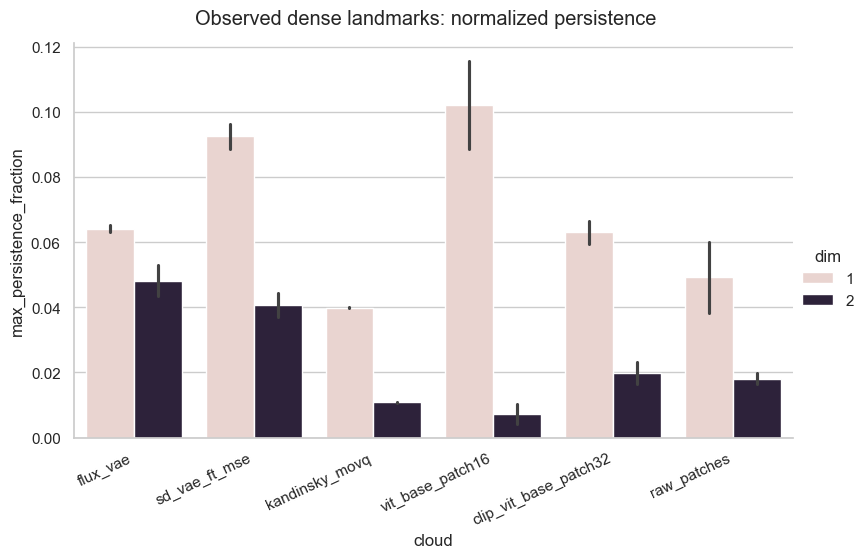

In [8]:
observed = summary[(summary["sample_kind"] == "observed_dense") & (summary["dim"].isin([1, 2]))].copy()

display(
    observed
    .groupby(["cloud", "family", "dim"])
    [["max_persistence_fraction", "n_finite", "pairwise_cv"]]
    .agg(["mean", "std"])
    .round(4)
)

g = sns.catplot(
    data=observed,
    x="cloud",
    y="max_persistence_fraction",
    hue="dim",
    kind="bar",
    height=4.8,
    aspect=1.7,
    sharey=False,
)
g.set_xticklabels(rotation=25, horizontalalignment="right")
g.fig.suptitle("Observed dense landmarks: normalized persistence", y=1.03)
plt.show()

## 8. Observed Versus Controls

A representation-level fingerprint is more interesting if it differs
from its own controls. This plot compares `H1` persistence against the
random-token, uniform-sphere, and diagonal-Gaussian baselines.

max_persistence_fraction          \
                                                         mean     std   
cloud                 sample_kind                                       
clip_vit_base_patch32 diag_gaussian                    0.0196  0.0009   
                      observed_dense                   0.0631  0.0050   
                      random_tokens                    0.0636  0.0139   
                      uniform_sphere                   0.0226  0.0013   
flux_vae              diag_gaussian                    0.1255  0.0171   
                      observed_dense                   0.0642  0.0016   
                      random_tokens                    0.1243  0.0371   
                      uniform_sphere                   0.1325  0.0111   
kandinsky_movq        diag_gaussian                    0.1855  0.0109   
                      observed_dense                   0.0399  0.0004   
                      random_tokens                    0.1957  0.0494   
                      uniform_sphere                   0.2247  0.0025   
raw_patches           diag_gaussian                    0.0233  0.0018   
                      observed_dense                   0.0492  0.0155   
                      random_tokens                    0.0595  0.0255   
                      uniform_sphere                   0.0226  0.0013   
sd_vae_ft_mse         diag_gaussian                    0.1739  0.0279   
                      observed_dense                   0.0925  0.0055   
                      random_tokens                    0.2056  0.0330   
                      uniform_sphere                   0.2247  0.0025   
vit_base_patch16      diag_gaussian                    0.0238  0.0005   
                      observed_dense                   0.1020  0.0191   
                      random_tokens                    0.1152  0.0253   
                      uniform_sphere                   0.0226  0.0013   

                                     top3_persistence         pairwise_cv  \
                                                 mean     std        mean   
cloud                 sample_kind                                           
clip_vit_base_patch32 diag_gaussian            0.0461  0.0006      0.0566   
                      observed_dense           0.1669  0.0145      0.1299   
                      random_tokens            0.1571  0.0266      0.1607   
                      uniform_sphere           0.0926  0.0009      0.0180   
flux_vae              diag_gaussian            0.4477  0.0005      0.1615   
                      observed_dense           0.2233  0.0124      0.3873   
                      random_tokens            0.4334  0.0499      0.2519   
                      uniform_sphere           0.5907  0.0624      0.1302   
kandinsky_movq        diag_gaussian            0.8862  0.0179      0.2992   
                      observed_dense           0.1941  0.0039      0.6591   
                      random_tokens            0.8740  0.1307      0.3163   
                      uniform_sphere           1.0478  0.0294      0.2880   
raw_patches           diag_gaussian            0.0794  0.0072      0.0214   
                      observed_dense           0.1008  0.0110      0.4514   
                      random_tokens            0.1440  0.0751      0.2756   
                      uniform_sphere           0.0926  0.0009      0.0180   
sd_vae_ft_mse         diag_gaussian            0.7748  0.0370      0.3156   
                      observed_dense           0.1577  0.0033      0.4303   
                      random_tokens            0.8838  0.0847      0.3469   
                      uniform_sphere           1.0478  0.0294      0.2880   
vit_base_patch16      diag_gaussian            0.0738  0.0003      0.0244   
                      observed_dense           0.2322  0.0082      0.2094   
                      random_tokens            0.3316  0.0427      0.1520   
                      uniform_sphere           0.0926  0.0009  

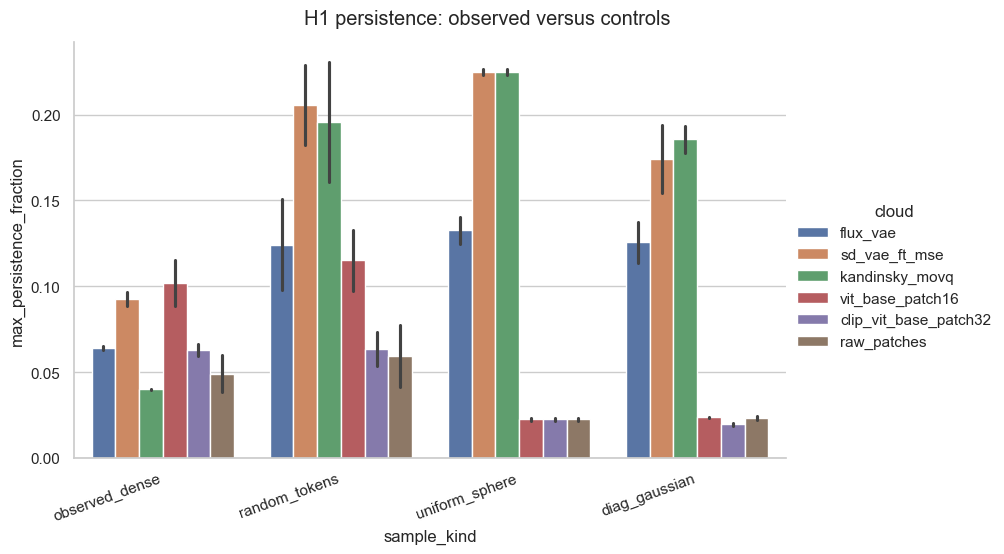

In [9]:
h1 = summary[summary["dim"] == 1].copy()

display(
    h1
    .groupby(["cloud", "sample_kind"])
    [["max_persistence_fraction", "top3_persistence", "pairwise_cv"]]
    .agg(["mean", "std"])
    .round(4)
)

g = sns.catplot(
    data=h1,
    x="sample_kind",
    y="max_persistence_fraction",
    hue="cloud",
    kind="bar",
    height=5.0,
    aspect=1.65,
    sharey=False,
)
g.set_xticklabels(rotation=20, horizontalalignment="right")
g.fig.suptitle("H1 persistence: observed versus controls", y=1.03)
plt.show()

## 9. Effect Sizes Against Uniform Sphere

The table below subtracts each representation's uniform-sphere control
from its observed dense-landmark summary. Positive values mean the
observed representation had stronger normalized persistence than a
random cloud in the same ambient dimension.

In [10]:
means = (
    summary[summary["dim"].isin([1, 2])]
    .groupby(["cloud", "family", "sample_kind", "dim"], as_index=False)
    ["max_persistence_fraction"]
    .mean()
)
observed_means = means[means["sample_kind"] == "observed_dense"].rename(columns={"max_persistence_fraction": "observed_mean"})
uniform_means = means[means["sample_kind"] == "uniform_sphere"][["cloud", "dim", "max_persistence_fraction"]].rename(columns={"max_persistence_fraction": "uniform_mean"})
random_means = means[means["sample_kind"] == "random_tokens"][["cloud", "dim", "max_persistence_fraction"]].rename(columns={"max_persistence_fraction": "random_token_mean"})

effect = (
    observed_means
    .merge(uniform_means, on=["cloud", "dim"], how="left")
    .merge(random_means, on=["cloud", "dim"], how="left")
)
effect["delta_vs_uniform"] = effect["observed_mean"] - effect["uniform_mean"]
effect["delta_vs_random_tokens"] = effect["observed_mean"] - effect["random_token_mean"]
effect = effect.sort_values(["dim", "delta_vs_uniform"], ascending=[True, False])
display(effect[["cloud", "family", "dim", "observed_mean", "uniform_mean", "random_token_mean", "delta_vs_uniform", "delta_vs_random_tokens"]].round(4))

,cloud,family,dim,observed_mean,uniform_mean,random_token_mean,delta_vs_uniform,delta_vs_random_tokens
10,vit_base_patch16,ViT,1,0.1020,0.0226,0.1152,0.0794,-0.0132
0,clip_vit_base_patch32,CLIPVision,1,0.0631,0.0226,0.0636,0.0405,-0.0005
6,raw_patches,RawPatches,1,0.0492,0.0226,0.0595,0.0266,-0.0103
2,flux_vae,AutoencoderKL,1,0.0642,0.1325,0.1243,-0.0683,-0.0601
8,sd_vae_ft_mse,AutoencoderKL,1,0.0925,0.2247,0.2056,-0.1323,-0.1131
4,kandinsky_movq,VQModel,1,0.0399,0.2247,0.1957,-0.1848,-0.1557
1,clip_vit_base_patch32,CLIPVision,2,0.0199,0.0116,0.0096,0.0082,0.0103
7,raw_patches,RawPatches,2,0.0181,0.0116,0.0000,0.0065,0.0181
11,vit_base_patch16,ViT,2,0.0072,0.0116,0.0126,-0.0044,-0.0054
3,flux_vae,AutoencoderKL,2,0.0482,0.0707,0.0502,-0.0225,-0.0020


## 10. Distance Concentration Check

High-dimensional clouds often have concentrated pairwise distances. If
distances are too concentrated, persistent features can be dominated by
finite-sample geometry rather than representation structure.

,cloud,family,channel_dim,seed,pairwise_mean,pairwise_std,pairwise_cv,threshold
1,flux_vae,AutoencoderKL,16,72,0.8510,0.3236,0.3802,1.1690
13,flux_vae,AutoencoderKL,16,73,0.8557,0.3375,0.3945,1.2121
25,sd_vae_ft_mse,AutoencoderKL,4,72,0.4718,0.2132,0.4519,0.6460
37,sd_vae_ft_mse,AutoencoderKL,4,73,0.4604,0.1882,0.4087,0.6407
49,kandinsky_movq,VQModel,4,72,0.9828,0.6435,0.6547,1.7937
61,kandinsky_movq,VQModel,4,73,0.9550,0.6336,0.6635,1.7715
73,vit_base_patch16,ViT,768,72,1.0340,0.2236,0.2163,1.2089
85,vit_base_patch16,ViT,768,73,1.0412,0.2108,0.2025,1.2158
97,clip_vit_base_patch32,CLIPVision,768,72,0.8313,0.1082,0.1302,0.9400
109,clip_vit_base_patch32,CLIPVision,768,73,0.8367,0.1084,0.1296,0.9484


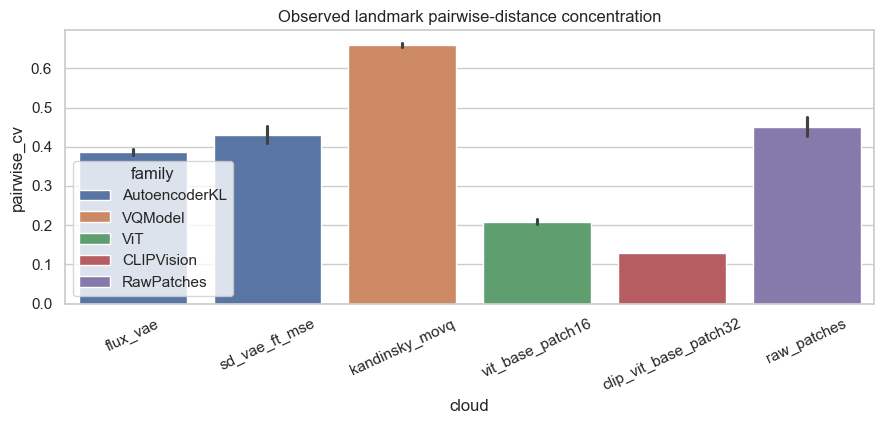

In [11]:
distance_view = summary[(summary["sample_kind"] == "observed_dense") & (summary["dim"] == 1)].copy()
display(distance_view[["cloud", "family", "channel_dim", "seed", "pairwise_mean", "pairwise_std", "pairwise_cv", "threshold"]].round(4))

fig, ax = plt.subplots(figsize=(9, 4.4))
sns.barplot(data=distance_view, x="cloud", y="pairwise_cv", hue="family", dodge=False, ax=ax)
ax.set_title("Observed landmark pairwise-distance concentration")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 11. Representative Diagrams

These are one-seed diagrams for the observed dense landmarks. They are
not the main evidence, but they make the summary table easier to inspect.

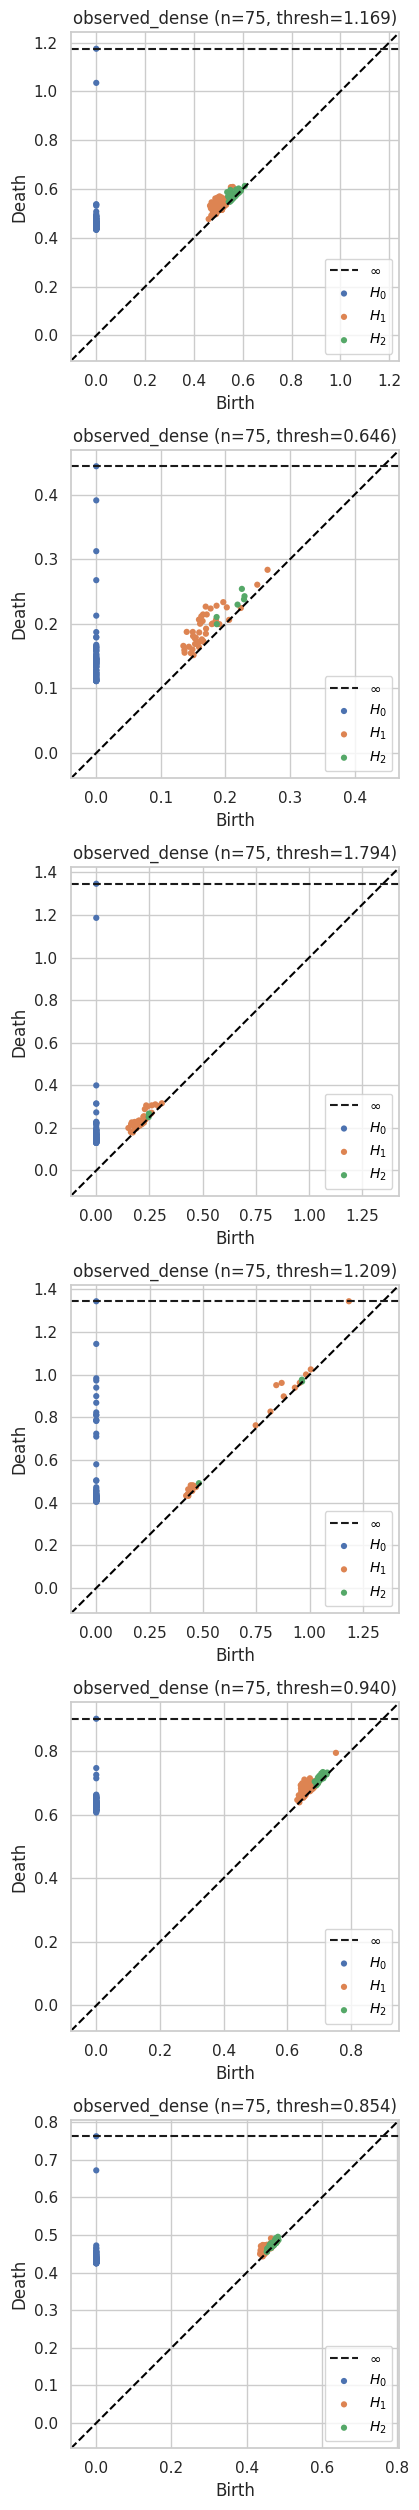

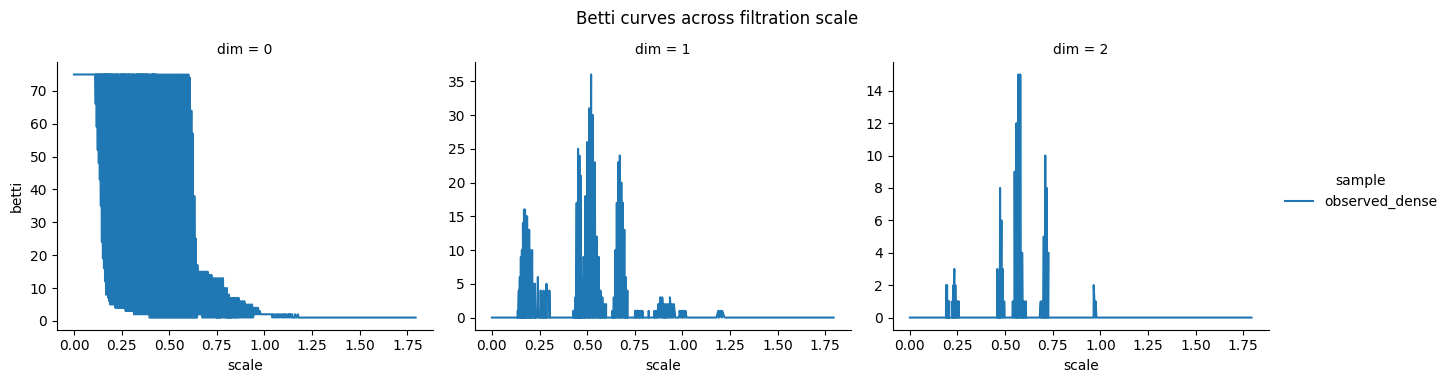

In [12]:
representative_seed = COMPARISON_SEEDS[0]
representative_results = [
    results[(cloud_name, representative_seed, "observed_dense")]
    for cloud_name in token_clouds
    if (cloud_name, representative_seed, "observed_dense") in results
]
plot_diagrams(representative_results)
plot_betti_curves(representative_results)

## 12. Longest Bars

The longest finite bars are useful for spotting outliers. They are not
enough for a claim, but they tell us which representation deserves
follow-up with cycle or landmark interpretation.

In [13]:
top_tables = []
for cloud_name in token_clouds:
    key = (cloud_name, representative_seed, "observed_dense")
    if key in results:
        top_tables.append(top_persistence_table(results[key], top_n=5).assign(cloud=cloud_name))
display(pd.concat(top_tables, ignore_index=True)[["cloud", "sample", "dim", "rank", "birth", "death", "persistence", "threshold"]].round(4))

,cloud,sample,dim,rank,birth,death,persistence,threshold
0,flux_vae,observed_dense,0,1,0.0000,1.0350,1.0350,1.1690
1,flux_vae,observed_dense,0,2,0.0000,0.5373,0.5373,1.1690
2,flux_vae,observed_dense,0,3,0.0000,0.5370,0.5370,1.1690
3,flux_vae,observed_dense,0,4,0.0000,0.5316,0.5316,1.1690
4,flux_vae,observed_dense,0,5,0.0000,0.5075,0.5075,1.1690
...,...,...,...,...,...,...,...,...
80,raw_patches,observed_dense,2,1,0.4776,0.4916,0.0140,0.8539
81,raw_patches,observed_dense,2,2,0.4610,0.4741,0.0131,0.8539
82,raw_patches,observed_dense,2,3,0.4652,0.4783,0.0130,0.8539
83,raw_patches,observed_dense,2,4,0.4831,0.4952,0.0122,0.8539


## 13. Readout

This notebook should be read as a prioritization tool. If one
representation is consistently above its controls, the next notebook
should map the relevant landmarks or cycles back to patches.

In [14]:
h1_effect = effect[effect["dim"] == 1].sort_values("delta_vs_uniform", ascending=False)
h2_effect = effect[effect["dim"] == 2].sort_values("delta_vs_uniform", ascending=False) if MAXDIM >= 2 else pd.DataFrame()

print("Runtime recap")
print(f"  encode seconds: {encode_seconds:.2f}")
print(f"  TDA seconds:    {tda_seconds:.2f}")
print(f"  diagram runs:   {len(results)}")
print()
print("H1 observed-minus-uniform ranking")
display(h1_effect[["cloud", "family", "observed_mean", "uniform_mean", "delta_vs_uniform", "delta_vs_random_tokens"]].round(4))
if not h2_effect.empty:
    print("H2 observed-minus-uniform ranking")
    display(h2_effect[["cloud", "family", "observed_mean", "uniform_mean", "delta_vs_uniform", "delta_vs_random_tokens"]].round(4))
print(
    "Interpretation prompt: prioritize representations whose observed dense landmarks beat both "
    "uniform and random-token controls across seeds; deprioritize apparent features that sit inside "
    "the control range."
)

Runtime recap
  encode seconds: 16.55
  TDA seconds:    2.13
  diagram runs:   48

H1 observed-minus-uniform ranking


,cloud,family,observed_mean,uniform_mean,delta_vs_uniform,delta_vs_random_tokens
10,vit_base_patch16,ViT,0.1020,0.0226,0.0794,-0.0132
0,clip_vit_base_patch32,CLIPVision,0.0631,0.0226,0.0405,-0.0005
6,raw_patches,RawPatches,0.0492,0.0226,0.0266,-0.0103
2,flux_vae,AutoencoderKL,0.0642,0.1325,-0.0683,-0.0601
8,sd_vae_ft_mse,AutoencoderKL,0.0925,0.2247,-0.1323,-0.1131
4,kandinsky_movq,VQModel,0.0399,0.2247,-0.1848,-0.1557


H2 observed-minus-uniform ranking


,cloud,family,observed_mean,uniform_mean,delta_vs_uniform,delta_vs_random_tokens
1,clip_vit_base_patch32,CLIPVision,0.0199,0.0116,0.0082,0.0103
7,raw_patches,RawPatches,0.0181,0.0116,0.0065,0.0181
11,vit_base_patch16,ViT,0.0072,0.0116,-0.0044,-0.0054
3,flux_vae,AutoencoderKL,0.0482,0.0707,-0.0225,-0.0020
9,sd_vae_ft_mse,AutoencoderKL,0.0407,0.0931,-0.0524,-0.0247
5,kandinsky_movq,VQModel,0.0109,0.0931,-0.0822,-0.1236


Interpretation prompt: prioritize representations whose observed dense landmarks beat both uniform and random-token controls across seeds; deprioritize apparent features that sit inside the control range.
